<a href="https://colab.research.google.com/github/LifeEngineer2069/DataTestRepo/blob/main/CompNeuro_NEURON_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NEURON Python Coding
This Google Colab notebook is an introduction into python coding for the NEURON python package. This python package is used in the paper:

*A Computational Model of the Escape Response Latency in the Giant Fiber System of Drosophila melanogaster* by Augustin H., Zylbertal, A., & Partridge, L.

This notebook will first go over how to use the NEURON python package in Google Colab. You do NOT need to install anything locally on your computer, all computation will be done in this notebook.

For a review of basic python coding principles for data science please review an example course: https://scrimba.com/learn-python-c03

# How to use this notebook

If you're accessing this in Google Colab, click `File - Save a copy in drive` to get a version that you can run for yourself.

Hit shift+enter to run each cell and move to the next cell or click the play symbol.

Some cells only have text (running them does nothing); others have code. All cells are editable if you're using your own copy.

In [ ]:
# Practice running your first cell!
print("Hello World!")

Hello World!


# Intro to NEURON Python Package
The NEURON Python package is used to simulate individual neurons and neural circuits using biologically realistic models of membrane dynamics and ion channels. It allows researchers to study how cellular properties and network connectivity give rise to behaviors like spiking, signal propagation, and response timing.

Let's create our first neuron!

In [ ]:
# First we need to install the python package into Google Colab
!pip install neuron

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 68.2 MB/s eta 0:00:00


Let's create a plot so we can visualize what is happening!

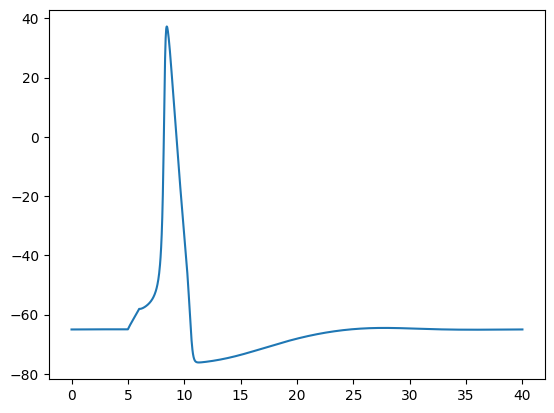

In [ ]:
from neuron import h
import matplotlib.pyplot as plt

# Load standard run system
h.load_file('stdrun.hoc')

# Create neuron
soma = h.Section(name='soma')
soma.L = soma.diam = 20
soma.insert('hh')

# Stimulus
stim = h.IClamp(soma(0.5))
stim.delay = 5
stim.dur = 1
stim.amp = 0.1

# Record
v = h.Vector().record(soma(0.5)._ref_v)
t = h.Vector().record(h._ref_t)

# Run
h.tstop = 40
h.run()

plt.plot(t, v)
plt.show()

# Creating a Circuit
In a more realistic model of neurons, they do not exist alone. Instead they exist in a circuit. Let's try creating a circuit of two neurons.

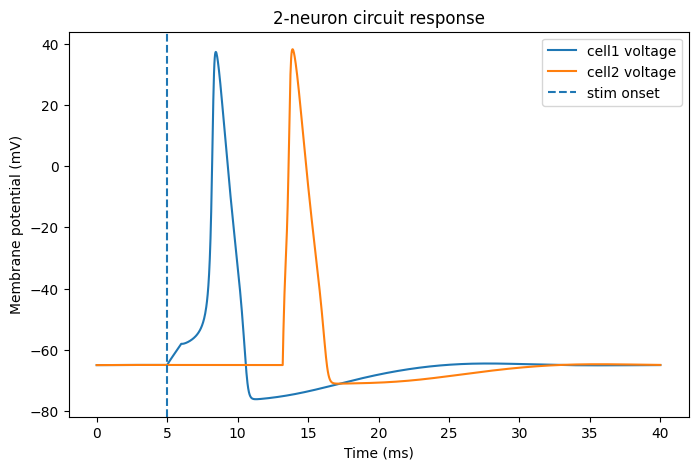

In [ ]:
from neuron import h
import matplotlib.pyplot as plt

h.load_file("stdrun.hoc")

# Create 2 neurons
cell1 = h.Section(name='cell1')
cell2 = h.Section(name='cell2')

for cell in [cell1, cell2]:
    cell.L = 20
    cell.diam = 20
    cell.insert('hh')

# Synapse on cell2
syn = h.ExpSyn(cell2(0.5))
syn.tau = 2
syn.e = 0

# Connect cell1 to synapse on cell2
nc = h.NetCon(cell1(0.5)._ref_v, syn, sec=cell1)
nc.threshold = 0
nc.weight[0] = 0.05
nc.delay = 5

# Stimulate cell1
stim = h.IClamp(cell1(0.5))
stim.delay = 5
stim.dur = 1
stim.amp = 0.1

# Record time and voltages
t = h.Vector().record(h._ref_t)
v1 = h.Vector().record(cell1(0.5)._ref_v)
v2 = h.Vector().record(cell2(0.5)._ref_v)

# Run simulation
h.dt = 0.025
h.finitialize(-65)
h.tstop = 40
h.run()

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, v1, label='cell1 voltage')
plt.plot(t, v2, label='cell2 voltage')
plt.axvline(stim.delay, linestyle='--', label='stim onset')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.title('2-neuron circuit response')
plt.legend()
plt.show()

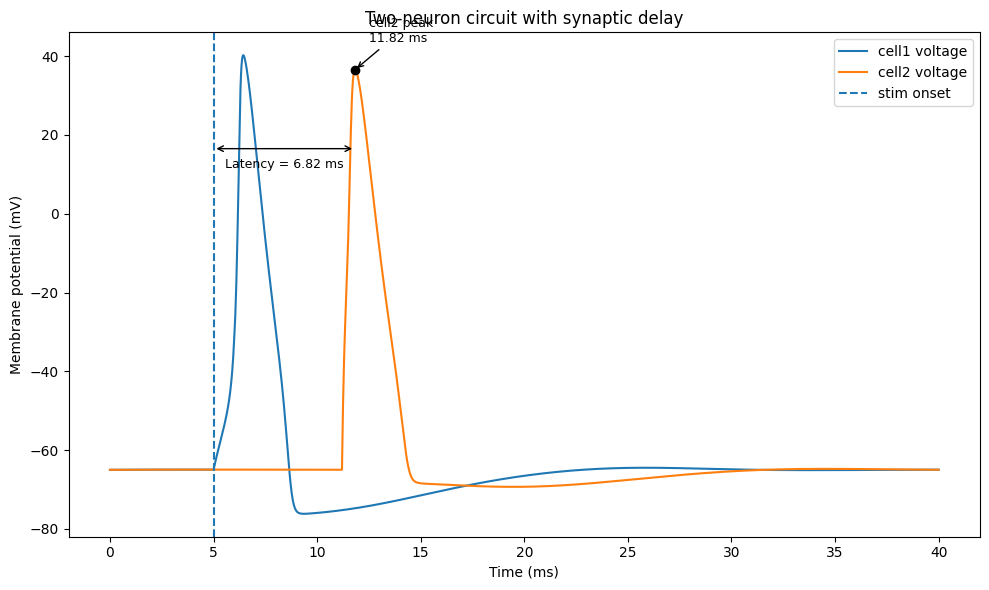

In [ ]:
from neuron import h
import matplotlib.pyplot as plt
import numpy as np

h.load_file("stdrun.hoc")

# Create 2 neurons
cell1 = h.Section(name='cell1')
cell2 = h.Section(name='cell2')

for cell in [cell1, cell2]:
    cell.L = 20
    cell.diam = 20
    cell.insert('hh')

# Synapse on cell2
syn = h.ExpSyn(cell2(0.5))
syn.tau = 2
syn.e = 0

# Connect cell1 to cell2
nc = h.NetCon(cell1(0.5)._ref_v, syn, sec=cell1)
nc.threshold = 0
nc.weight[0] = 0.08
nc.delay = 5   # ms

# Stimulate cell1
stim = h.IClamp(cell1(0.5))
stim.delay = 5   # ms
stim.dur = 1     # ms
stim.amp = 0.3   # nA

# Record
t = h.Vector().record(h._ref_t)
v1 = h.Vector().record(cell1(0.5)._ref_v)
v2 = h.Vector().record(cell2(0.5)._ref_v)

# Run
h.dt = 0.025
h.finitialize(-65)
h.tstop = 40
h.run()

# Convert to numpy
t_np = np.array(t)
v1_np = np.array(v1)
v2_np = np.array(v2)

# Find cell2 peak after stimulus onset
post_idx = np.where(t_np >= stim.delay)[0]
peak_idx_rel = np.argmax(v2_np[post_idx])
peak_idx = post_idx[peak_idx_rel]

peak_time = t_np[peak_idx]
peak_voltage = v2_np[peak_idx]
latency = peak_time - stim.delay

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t_np, v1_np, label='cell1 voltage')
plt.plot(t_np, v2_np, label='cell2 voltage')

# Stimulus onset
plt.axvline(stim.delay, linestyle='--', label='stim onset')

# Peak marker
plt.plot(peak_time, peak_voltage, 'o', color='black')

# Peak label (offset, no overlap)
plt.annotate(
    f'cell2 peak\n{peak_time:.2f} ms',
    xy=(peak_time, peak_voltage),
    xytext=(10, 20),  # offset in points
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->'),
    fontsize=9
)

# Latency arrow (lower it to avoid overlap)
y_arrow = peak_voltage - 20

plt.annotate(
    '',
    xy=(stim.delay, y_arrow),
    xytext=(peak_time, y_arrow),
    arrowprops=dict(arrowstyle='<->')
)

# Latency text BELOW arrow
plt.text(
    (stim.delay + peak_time) / 2,
    y_arrow - 5,
    f'Latency = {latency:.2f} ms',
    ha='center',
    fontsize=9
)

plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.title('Two-neuron circuit with synaptic delay')
plt.legend()

plt.tight_layout()
plt.show()

# Recreate figures from the paper
Try and recreate similar figures from the paper

No valid latencies detected. Increase weights or lower threshold.


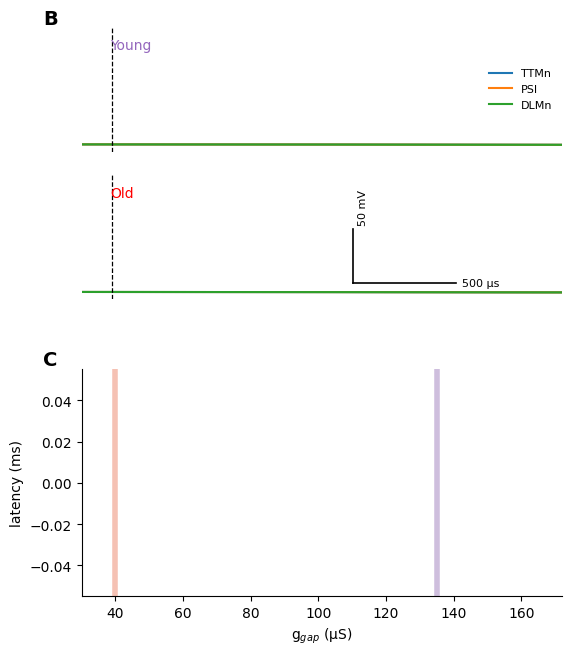

In [ ]:
from neuron import h
import numpy as np
import matplotlib.pyplot as plt

h.load_file("stdrun.hoc")

# --------------------------------------------------
# Helper: build simplified GFS-like circuit
# GF -> TTMn  (direct fast branch)
# GF -> PSI -> DLMn (indirect slower branch)
# --------------------------------------------------

def build_circuit(g_gap_uS):
    gnorm = g_gap_uS / 135.0

    gf   = h.Section(name="GF")
    ttmn = h.Section(name="TTMn")
    psi  = h.Section(name="PSI")
    dlmn = h.Section(name="DLMn")

    cells = [gf, ttmn, psi, dlmn]

    for sec in cells:
        sec.L = 20
        sec.diam = 20
        sec.Ra = 100
        sec.cm = 1
        sec.insert("hh")

        for seg in sec:
            seg.hh.gnabar = 0.12
            seg.hh.gkbar  = 0.036
            seg.hh.gl     = 0.0003
            seg.hh.el     = -54.3

    # Make downstream cells a bit easier to excite
    for seg in ttmn:
        seg.hh.gnabar = 0.12
        seg.hh.gkbar  = 0.030

    for seg in psi:
        seg.hh.gnabar = 0.12
        seg.hh.gkbar  = 0.030

    for seg in dlmn:
        seg.hh.gnabar = 0.12
        seg.hh.gkbar  = 0.030

    # Stimulate GF
    stim = h.IClamp(gf(0.5))
    stim.delay = 5.0
    stim.dur   = 0.5
    stim.amp   = 2.0

    # GF -> TTMn
    syn_ttm = h.Exp2Syn(ttmn(0.5))
    syn_ttm.tau1 = 0.03
    syn_ttm.tau2 = 0.20
    syn_ttm.e = 0

    nc_ttm = h.NetCon(gf(0.5)._ref_v, syn_ttm, sec=gf)
    nc_ttm.threshold = 0
    nc_ttm.delay = 0.05
    nc_ttm.weight[0] = 0.25 * gnorm

    # GF -> PSI
    syn_psi = h.Exp2Syn(psi(0.5))
    syn_psi.tau1 = 0.05
    syn_psi.tau2 = 0.25
    syn_psi.e = 0

    nc_psi = h.NetCon(gf(0.5)._ref_v, syn_psi, sec=gf)
    nc_psi.threshold = 0
    nc_psi.delay = 0.08
    nc_psi.weight[0] = 0.22 * gnorm

    # PSI -> DLMn
    syn_dlm = h.Exp2Syn(dlmn(0.5))
    syn_dlm.tau1 = 0.08
    syn_dlm.tau2 = 0.35
    syn_dlm.e = 0

    nc_dlm = h.NetCon(psi(0.5)._ref_v, syn_dlm, sec=psi)
    nc_dlm.threshold = 0
    nc_dlm.delay = 0.12
    nc_dlm.weight[0] = 0.20 * gnorm

    return gf, ttmn, psi, dlmn, stim


# More forgiving latency detector
def first_response_latency_ms(t, v, stim_delay, threshold=-20):
    t = np.asarray(t)
    v = np.asarray(v)

    idx = np.where(t >= stim_delay)[0]
    if len(idx) == 0:
        return np.nan

    t_post = t[idx]
    v_post = v[idx]

    crossings = np.where((v_post[:-1] < threshold) & (v_post[1:] >= threshold))[0]
    if len(crossings) == 0:
        return np.nan

    i = crossings[0] + 1
    return t_post[i] - stim_delay


def run_once(g_gap_uS, tstop=12):
    gf, ttmn, psi, dlmn, stim = build_circuit(g_gap_uS)

    t      = h.Vector().record(h._ref_t)
    v_gf   = h.Vector().record(gf(0.5)._ref_v)
    v_ttm  = h.Vector().record(ttmn(0.5)._ref_v)
    v_psi  = h.Vector().record(psi(0.5)._ref_v)
    v_dlm  = h.Vector().record(dlmn(0.5)._ref_v)

    h.dt = 0.005
    h.finitialize(-65)
    h.tstop = tstop
    h.run()

    t_np    = np.array(t)
    gf_np   = np.array(v_gf)
    ttm_np  = np.array(v_ttm)
    psi_np  = np.array(v_psi)
    dlm_np  = np.array(v_dlm)

    lat_ttm = first_response_latency_ms(t_np, ttm_np, stim.delay, threshold=-20)
    lat_dlm = first_response_latency_ms(t_np, dlm_np, stim.delay, threshold=-20)

    return {
        "t": t_np,
        "GF": gf_np,
        "TTMn": ttm_np,
        "PSI": psi_np,
        "DLMn": dlm_np,
        "stim_delay": stim.delay,
        "lat_ttm": lat_ttm,
        "lat_dlm": lat_dlm,
    }


def shift_trace_by_latency(t, v, stim_delay, threshold=-20):
    lat = first_response_latency_ms(t, v, stim_delay, threshold)
    if np.isnan(lat):
        return t - stim_delay, v, lat
    return t - stim_delay - lat, v, lat


# --------------------------------------------------
# Sweep g_gap and build panel C
# --------------------------------------------------

g_vals = np.linspace(35, 160, 40)

lat_ttm = []
lat_dlm = []

for g in g_vals:
    out = run_once(g)
    lat_ttm.append(out["lat_ttm"])
    lat_dlm.append(out["lat_dlm"])

lat_ttm = np.array(lat_ttm)
lat_dlm = np.array(lat_dlm)

g_old = 40
g_young = 135

old_out = run_once(g_old)
young_out = run_once(g_young)

old_ttm_lat   = old_out["lat_ttm"]
young_ttm_lat = young_out["lat_ttm"]
old_dlm_lat   = old_out["lat_dlm"]
young_dlm_lat = young_out["lat_dlm"]


# --------------------------------------------------
# Plot panel B and C
# --------------------------------------------------

fig = plt.figure(figsize=(6.2, 7.4))
gs = fig.add_gridspec(2, 1, height_ratios=[1.2, 1.0], hspace=0.28)

# ---------------- Panel B ----------------
subgs = gs[0].subgridspec(2, 1, hspace=0.18)
axB1 = fig.add_subplot(subgs[0])
axB2 = fig.add_subplot(subgs[1])

def draw_panel_B(ax, out, label_text, label_color):
    t = out["t"]
    stim_delay = out["stim_delay"]

    x_ttm, y_ttm, _ = shift_trace_by_latency(t, out["TTMn"], stim_delay, threshold=-20)
    x_psi, y_psi, _ = shift_trace_by_latency(t, out["PSI"], stim_delay, threshold=-20)
    x_dlm, y_dlm, _ = shift_trace_by_latency(t, out["DLMn"], stim_delay, threshold=-20)

    mask_ttm = (x_ttm >= -0.15) & (x_ttm <= 2.2)
    mask_psi = (x_psi >= -0.15) & (x_psi <= 2.2)
    mask_dlm = (x_dlm >= -0.15) & (x_dlm <= 2.2)

    ax.plot(x_ttm[mask_ttm], y_ttm[mask_ttm], lw=1.5, label="TTMn")
    ax.plot(x_psi[mask_psi], y_psi[mask_psi], lw=1.5, label="PSI")
    ax.plot(x_dlm[mask_dlm], y_dlm[mask_dlm], lw=1.5, label="DLMn")

    ax.axvline(0, color="k", ls="--", lw=0.9)
    ax.text(0.06, 0.82, label_text, color=label_color, transform=ax.transAxes, fontsize=10)

    ax.set_xlim(-0.15, 2.2)
    ax.set_ylim(-70, 45)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

draw_panel_B(axB1, young_out, "Young", "tab:purple")
draw_panel_B(axB2, old_out,   "Old",   "red")

axB1.legend(frameon=False, loc="center right", fontsize=8)
axB2.plot([1.18, 1.68], [-55, -55], color="k", lw=1.2)
axB2.plot([1.18, 1.18], [-55, -5], color="k", lw=1.2)
axB2.text(1.71, -55, "500 µs", va="center", fontsize=8)
axB2.text(1.20, -2, "50 mV", rotation=90, va="bottom", fontsize=8)

axB1.text(-0.08, 1.02, "B", transform=axB1.transAxes, fontsize=14, fontweight="bold")

# ---------------- Panel C ----------------
axC = fig.add_subplot(gs[1])

axC.plot(g_vals, lat_ttm, lw=1.6, label="TTMn")
axC.plot(g_vals, lat_dlm, lw=1.6, label="DLMn")

axC.axvline(g_old,   color="#f4b6a6", lw=4, alpha=0.85)
axC.axvline(g_young, color="#c6b3d8", lw=4, alpha=0.85)

if np.isfinite(old_dlm_lat):
    axC.axhline(old_dlm_lat, ls="--", lw=1.0, color="tab:green", alpha=0.7)
if np.isfinite(young_dlm_lat):
    axC.axhline(young_dlm_lat, ls="--", lw=1.0, color="tab:green", alpha=0.7)
if np.isfinite(old_ttm_lat):
    axC.axhline(old_ttm_lat, ls="--", lw=1.0, color="tab:blue", alpha=0.7)
if np.isfinite(young_ttm_lat):
    axC.axhline(young_ttm_lat, ls="--", lw=1.0, color="tab:blue", alpha=0.7)

valid_ttm = lat_ttm[np.isfinite(lat_ttm)]
valid_dlm = lat_dlm[np.isfinite(lat_dlm)]

if len(valid_ttm) == 0 and len(valid_dlm) == 0:
    print("No valid latencies detected. Increase weights or lower threshold.")
else:
    ymax_text = max(
        np.max(valid_ttm) if len(valid_ttm) else -np.inf,
        np.max(valid_dlm) if len(valid_dlm) else -np.inf
    )

    axC.text(g_old - 4, ymax_text + 0.02, "Old", color="red", fontsize=10)
    axC.text(g_young - 8, ymax_text + 0.02, "Young", color="tab:purple", fontsize=10)

    if len(valid_dlm):
        axC.text(g_vals[-1] + 2, valid_dlm[-1], "DLM", color="tab:green", va="center", fontsize=10)
    if len(valid_ttm):
        axC.text(g_vals[-1] + 2, valid_ttm[-1], "TTM", color="tab:blue", va="center", fontsize=10)

    ymin = min(
        np.min(valid_ttm) if len(valid_ttm) else np.inf,
        np.min(valid_dlm) if len(valid_dlm) else np.inf
    ) - 0.05
    ymax = max(
        np.max(valid_ttm) if len(valid_ttm) else -np.inf,
        np.max(valid_dlm) if len(valid_dlm) else -np.inf
    ) + 0.08

    axC.set_ylim(ymin, ymax)

axC.set_xlabel(r"g$_{gap}$ (µS)")
axC.set_ylabel("latency (ms)")
axC.set_xlim(g_vals[0] - 5, g_vals[-1] + 12)

axC.spines["top"].set_visible(False)
axC.spines["right"].set_visible(False)
axC.text(-0.08, 1.02, "C", transform=axC.transAxes, fontsize=14, fontweight="bold")

plt.show()

# Challenge Problems
Try and solve these problems by filling in the code.

## Problem 1
Fill in the missing lines to create a neuron that fires an action potential when stimulated.

In [ ]:
from neuron import h
import matplotlib.pyplot as plt

h.load_file("stdrun.hoc")

# Create neuron
soma = h.Section(name='soma')
soma.L = 20
soma.diam = 20

# INSERT CHANNELS
# ??? (add Hodgkin-Huxley mechanism)

# Stimulate neuron
stim = h.IClamp(soma(0.5))
stim.delay = 5
stim.dur = 1
stim.amp = ___   # choose value to cause spike

# Record
t = h.Vector().record(h._ref_t)
v = h.Vector().record(soma(0.5)._ref_v)

# Run
h.finitialize(-65)
h.tstop = 40
h.run()

plt.plot(t, v)
plt.show()

## Problem 2
Complete the code so that cell1 activates cell2 through a synapse.

In [ ]:
from neuron import h

h.load_file("stdrun.hoc")

# Create neurons
cell1 = h.Section(name='cell1')
cell2 = h.Section(name='cell2')

for c in [cell1, cell2]:
    c.insert('hh')

# Stimulate cell1
stim = h.IClamp(cell1(0.5))
stim.delay = 5
stim.dur = 1
stim.amp = 0.3

# Create synapse on cell2
syn = ___   # create ExpSyn

# Connect cell1 → cell2
nc = h.NetCon(____, syn, sec=cell1)

nc.weight[0] = ___
nc.delay = ___


## Problem 3
Modify the circuit so that:

cell2 spikes AFTER cell1
latency ≈ 10 ms

Fill in missing parameters.

In [ ]:
# Adjust parameters to achieve ~10 ms latency

nc.weight[0] = ___   # strong enough to spike
nc.delay = ___       # control latency

# Optional: adjust stimulus strength
stim.amp = ___

## Answer Key
Answers to problems below

In [ ]:
# Problem 1
soma.insert('hh')
stim.amp = 0.3

In [ ]:
# Problem 2
syn = h.ExpSyn(cell2(0.5))
nc = h.NetCon(cell1(0.5)._ref_v, syn, sec=cell1)
nc.weight[0] = 0.1
nc.delay = 5

In [ ]:
# Problem 3
nc.weight[0] = 0.15
nc.delay = 10
stim.amp = 0.4